# Chargement des données


## Définition des paramètres


In [1]:
# 1. Liste des pays de la CEMAC (Codes ISO-3)
pays_cemac = {
    "CMR": "Cameroun",
    "CAF": "Rép. Centrafricaine",
    "COG": "Congo",
    "GAB": "Gabon",
    "GNQ": "Guinée Équatoriale",
    "TCD": "Tchad",
}

# 2. Sélection des indicateurs macro-financiers clés
indicateur = {
    "NY.GDP.MKTP.CD": "PIB_USD",  # PIB nominal (USD)
    "NY.GDP.MKTP.KD.ZG": "Croissance_PIB_pct",  # Taux de croissance du PIB (%)
    "FP.CPI.TOTL.ZG": "Inflation_pct",  # Taux d'inflation annuel (%)
    "FS.AST.PRVT.GD.ZS": "Credit_Secteur_Prive_pct_PIB",  # Profondeur financière
    "BN.CAB.XOKA.GD.ZS": "Solde_Courant_pct_PIB",  # Balance courante (% PIB)
    "FI.RES.TOTL.CD": "Reserves_Change_USD",  # Réserves brutes en devises
}

## Fonction d'extraction

In [2]:
import pandas as pd
import requests


# Fonction de collecte via l'API REST de la Banque Mondiale

def extract_data(pays, indicateur, start_year=2000, end_year=2025):
    all_records = []
    country_str = ";".join(pays.keys())
    
    for code, name in indicateur.items():
        url = (
            f"http://api.worldbank.org/v2/country/{country_str}/indicator/{code}"
            f"?date={start_year}:{end_year}&format=json&per_page=1000"
        )
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
            # L'API retourne une liste : metadata en index 0, données en index 1
            if len(data) > 1 and data[1]:
                for entry in data[1]:
                    all_records.append({
                        "Code_Pays": entry["countryiso3code"],
                        "Pays": pays_cemac.get(entry["countryiso3code"], entry["country"]["value"]),
                        "Annee": int(entry["date"]),
                        "Indicateur": name,
                        "Valeur": entry["value"]
                    })

    # Conversion en DataFrame pandas
    df_raw = pd.DataFrame(all_records)
    
    # Restructuration pour obtenir une ligne par (Pays, Année)
    df_pivot = df_raw.pivot(
        index=["Code_Pays", "Pays", "Annee"], 
        columns="Indicateur", 
        values="Valeur"
    ).reset_index()
    
    # Tri par pays
    return df_pivot.sort_values(by=["Code_Pays", "Annee"]).reset_index(drop=True)

## Exécution de la collecte

In [3]:
df = extract_data(pays_cemac, indicateur, start_year=1975, end_year=2025)
df.head()


Indicateur,Code_Pays,Pays,Annee,Credit_Secteur_Prive_pct_PIB,Croissance_PIB_pct,Inflation_pct,PIB_USD,Reserves_Change_USD,Solde_Courant_pct_PIB
0,CAF,Rép. Centrafricaine,1975,16.426022,0.404987,NaN,3.786600e+08,3.828943e+06,NaN
1,CAF,Rép. Centrafricaine,1976,11.170365,5.432519,NaN,4.511525e+08,1.882869e+07,NaN
2,CAF,Rép. Centrafricaine,1977,11.817912,3.806235,NaN,5.072981e+08,2.627457e+07,-3.724540
3,CAF,Rép. Centrafricaine,1978,13.236982,1.209235,NaN,6.105786e+08,2.605479e+07,-3.764680
4,CAF,Rép. Centrafricaine,1979,10.478451,-2.465138,NaN,7.007647e+08,4.994603e+07,-2.276816


## Enrégistrement des données en csv

In [4]:
df.to_csv("macro_financial_data_cemac.csv", index=False)

# Analyse Exploratoire


In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png" # Définition du rendu par défaut pour VsCode

## Inspection des données

In [6]:
df = pd.read_csv("macro_financial_data_cemac.csv")
df.head()

,Code_Pays,Pays,Annee,Credit_Secteur_Prive_pct_PIB,Croissance_PIB_pct,Inflation_pct,PIB_USD,Reserves_Change_USD,Solde_Courant_pct_PIB
0,CAF,Rép. Centrafricaine,1975,16.426022,0.404987,NaN,3.786600e+08,3.828943e+06,NaN
1,CAF,Rép. Centrafricaine,1976,11.170365,5.432519,NaN,4.511525e+08,1.882869e+07,NaN
2,CAF,Rép. Centrafricaine,1977,11.817912,3.806235,NaN,5.072981e+08,2.627457e+07,-3.724540
3,CAF,Rép. Centrafricaine,1978,13.236982,1.209235,NaN,6.105786e+08,2.605479e+07,-3.764680
4,CAF,Rép. Centrafricaine,1979,10.478451,-2.465138,NaN,7.007647e+08,4.994603e+07,-2.276816


In [7]:
df.shape

(306, 9)

In [8]:
df_info = pd.DataFrame({
    "Type" : df.dtypes,
    "Valeurs manquantes" : df.isnull().sum(),
    "Taux de valeurs manquantes (%)" : (df.isnull().sum() / len(df) * 100).round(2)
})
display(df_info)

,Type,Valeurs manquantes,Taux de valeurs manquantes (%)
Code_Pays,object,0,0.00
Pays,object,0,0.00
Annee,int64,0,0.00
Credit_Secteur_Prive_pct_PIB,float64,33,10.78
Croissance_PIB_pct,float64,6,1.96
Inflation_pct,float64,40,13.07
PIB_USD,float64,2,0.65
Reserves_Change_USD,float64,13,4.25
Solde_Courant_pct_PIB,float64,133,43.46


## Statistiques descriptives

In [9]:
df_recent = df[df["Annee"] >= 2000].copy() # Filtrage des données à partir de l'année 2000
indicateurs = ["PIB_USD", "Croissance_PIB_pct", "Inflation_pct", "Credit_Secteur_Prive_pct_PIB", "Solde_Courant_pct_PIB", "Reserves_Change_USD"]
stat_pays = df_recent.groupby("Pays")[indicateurs].agg(["mean", "std"]).round(2)
display(stat_pays)




PIB_USD               Croissance_PIB_pct         \
                             mean           std               mean    std   
Pays                                                                        
Cameroun             3.154087e+10  1.286890e+10               3.89   1.32   
Congo                1.145703e+10  4.968011e+09               2.45   5.34   
Gabon                1.420548e+10  5.103342e+09               2.20   2.85   
Guinée Équatoriale   1.217855e+10  6.300969e+09               6.35  16.50   
Rép. Centrafricaine  1.928154e+09  5.868096e+08               1.32   8.20   
Tchad                1.278366e+10  5.954250e+09               5.76   7.77   

                    Inflation_pct       Credit_Secteur_Prive_pct_PIB        \
                             mean   std                         mean   std   
Pays                                                                         
Cameroun                     2.72  1.84                        10.82  2.78   
Congo                        2.55  1.87                         8.53  5.29   
Gabon                        2.12  1.75                        11.24  2.26   
Guinée Équatoriale           4.08  2.36                         7.29  4.44   
Rép. Centrafricaine          3.72  3.27                         9.34  2.86   
Tchad                        3.14  5.51                         4.90  2.48   

                    Solde_Courant_pct_PIB        Reserves_Change_USD  \
                                     mean    std                mean   
Pays                                                                   
Cameroun                            -2.90   1.37        2.858163e+09   
Congo                                2.14  16.43        1.910732e+09   
Gabon                               12.82   6.81        1.287782e+09   
Guinée Équatoriale                    NaN    NaN        1.636584e+09   
Rép. Centrafricaine                   NaN    NaN        2.448653e+08   
Tchad                                 NaN    NaN        5.893651e+08   

                                   
                              std  
Pays                               
Cameroun             1.496027e+09  
Congo                1.955461e+09  
Gabon                7.892108e+08  
Guinée Équatoriale   1.625532e+09  
Rép. Centrafricaine  1.302488e+08  
Tchad                4.679244e+08

## Croissance du PIB

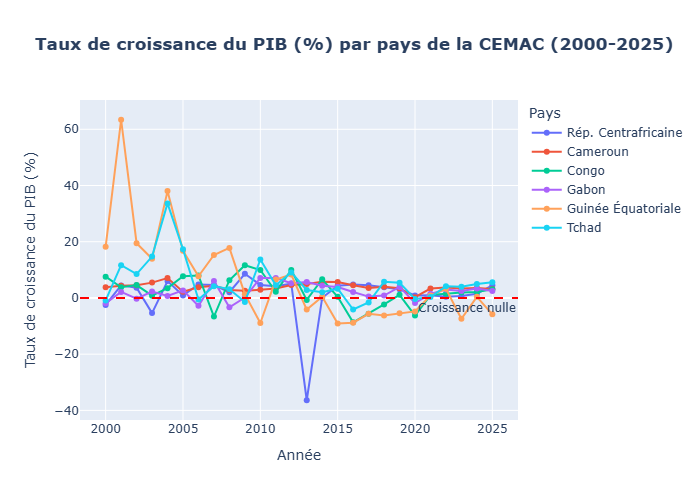

In [10]:
fig_croissance = px.line(
    df_recent,
    x="Annee",
    y="Croissance_PIB_pct",
    color="Pays",
    markers=True,
    title="<b>Taux de croissance du PIB (%) par pays de la CEMAC (2000-2025)</b>",
    labels={"Annee": "Année", "Croissance_PIB_pct": "Taux de croissance du PIB (%)", "Pays": "Pays"},
    hover_data = {"PIB_USD" : ":,.0f"}
)

fig_croissance.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Croissance nulle", annotation_position="bottom right")
fig_croissance.update_layout(
    legend_title_text="Pays", 
    hovermode="x unified",
    legend_title = "Pays"
)
fig_croissance.show()

## Inflation et critères de convergence

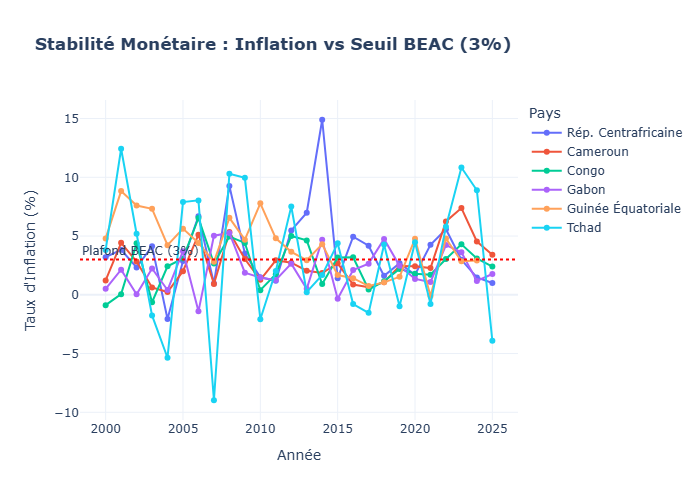

In [11]:
fig_inflation = px.line(
    df_recent, 
    x='Annee', 
    y='Inflation_pct', 
    color='Pays',
    markers=True,
    title="<b>Stabilité Monétaire : Inflation vs Seuil BEAC (3%)</b>",
    labels={'Inflation_pct': 'Taux d\'Inflation (%)', 'Annee': 'Année'}
)

# Ajout du critère de convergence communautaire BEAC (3%)
fig_inflation.add_hline(
    y=3.0, 
    line_dash="dot", 
    line_color="red", 
    line_width=2,
    annotation_text="Plafond BEAC (3%)", 
    annotation_position="top left"
)

fig_inflation.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig_inflation.show()

## Distribution des réserves de change

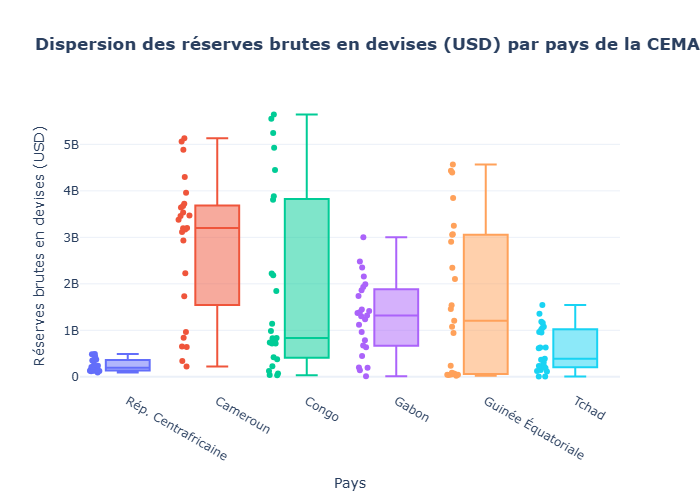

In [12]:
fig_reserves = px.box(
    df_recent,
    x = "Pays",
    y = "Reserves_Change_USD",
    color = "Pays",
    points = "all",
    title="<b>Dispersion des réserves brutes en devises (USD) par pays de la CEMAC (2000-2025)</b>",
    labels={"Reserves_Change_USD": "Réserves brutes en devises (USD)", "Pays": "Pays"}
)
fig_reserves.update_layout(
    template="plotly_white",
    hovermode="x unified",
    showlegend=False
)
fig_reserves.show()

## Matrice de corrélation Interdépendante

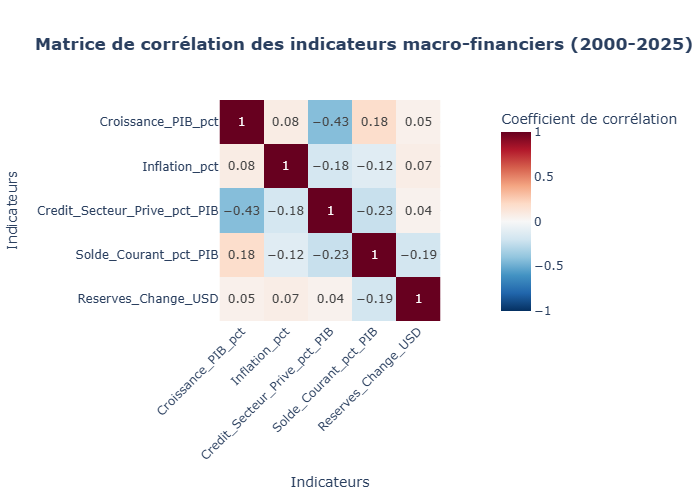

In [13]:
cols_num = ["Croissance_PIB_pct", "Inflation_pct", "Credit_Secteur_Prive_pct_PIB", "Solde_Courant_pct_PIB", "Reserves_Change_USD"]
corr_matrix = df_recent[cols_num].corr().round(2)

fig_corr = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="<b>Matrice de corrélation des indicateurs macro-financiers (2000-2025)</b>",
    labels={"color": "Coefficient de corrélation"}
)
fig_corr.update_layout(
    template="plotly_white",
    xaxis_title="Indicateurs",
    yaxis_title="Indicateurs",
    xaxis=dict(tickangle=-45)
)
fig_corr.show()